In [1]:
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM
from os import path
import math
import time
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import optimize
from classifier import *
from utils import *

In [2]:
from sklearn.mixture import GaussianMixture

In [3]:
py4DSTEM.__version__

'0.12.6'

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [8.0, 6.0]

## Data Loading

In [5]:
#import and read data
file_folder = "/Users/weiliu/OneDrive - Northwestern University/Research/Highthroughput/4DSTEM/"
file_name = "Au30Ag10Co20Ni40/SI data (63)/Diffraction SI.dm4"
filepath_input = file_folder+file_name
datacube = py4DSTEM.io.read(filepath_input)

## Particle Identification

In [6]:
#look at data without margin area
datacube_origin = datacube.data[8:-8, 8:-8,:,:]

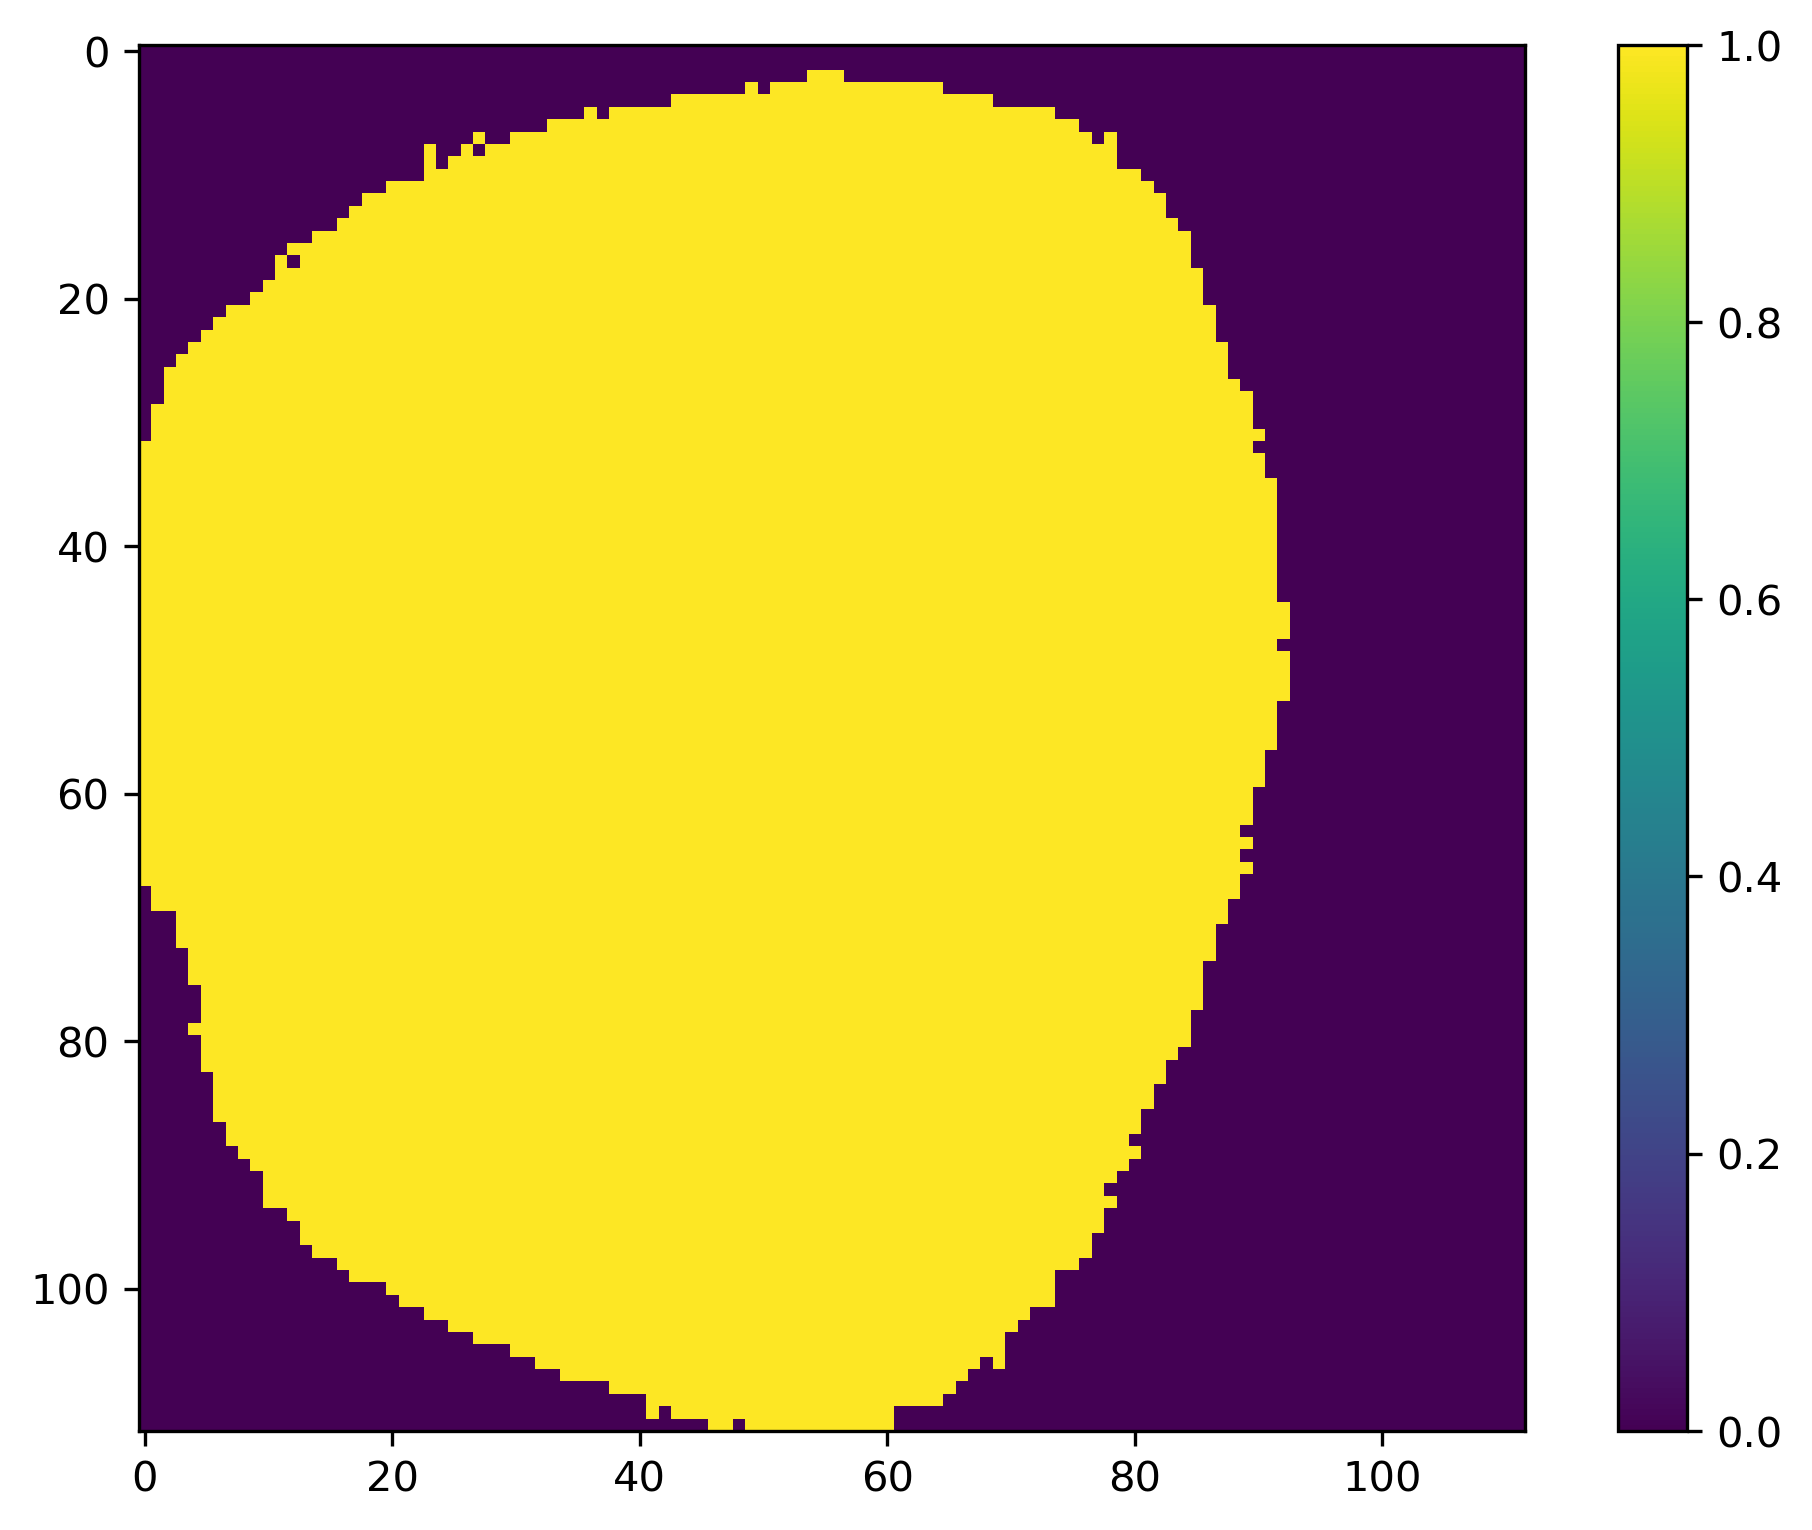

In [7]:
#threshold pixel values to indicate if a pixel belongs to particle area or not
particle_labels = IsParticle(datacube_origin, thres=60000)
plt.imshow(particle_labels);plt.colorbar()

## Average

In [8]:
#datacube_average: after spatially smoothing
#datacube_info: stores average info separately for display
#py4DSTEM function modifies the data in place
#so always keep storage separately if there is display needs in the future
datacube_average, datacube_info = average_datacube(datacube, n=8)

In [9]:
#obtain the probe (kernel)
#use py4dstem functions
#obtain the center coordinates and assign to origin_x, origin_y
probe = py4DSTEM.process.diskdetection.get_probe_from_vacuum_4Dscan(datacube, mask_threshold=0.002, verbose = False)
probe_kernel = py4DSTEM.process.diskdetection.get_probe_kernel_edge_gaussian(probe, sigma_probe_scale=2)
probe_kernel_FT = np.conj(np.fft.fft2(probe_kernel))
n = np.argmax(probe.flatten())
origin_x, origin_y = np.unravel_index(n, datacube_average.data.shape[2:])

100%|████████████████████████████████████| 12543/12543 [00:21<00:00, 592.87it/s]


In [10]:
#recenter each DP at [origin_x, origin_y]
datacube_symmetrize = datacube_average
        
#first recenter each DP at [origin_x, origin_y]
for n in py4DSTEM.process.utils.tqdmnd(range(datacube_average.R_N)):
    Rx, Ry = np.unravel_index(n, datacube_average.data.shape[:2])
    intensity = py4DSTEM.process.utils.get_cross_correlation_fk(datacube_average.data[Rx,Ry],probe_kernel_FT,corrPower=1)
    orig_intensity = intensity[origin_x,origin_y]
    curr_orig_x, curr_orig_y = origin_x, origin_y
    for w_x in range(origin_x-4,origin_x+4):
        for w_y in range(origin_y-4,origin_y+4):
            if intensity[w_x,w_y] > orig_intensity:
                curr_orig_x, curr_orig_y = w_x, w_y
                orig_intensity = intensity[w_x,w_y]
    shift_x, shift_y = origin_x - curr_orig_x, origin_y - curr_orig_y
    datacube_symmetrize.data[Rx][Ry] = get_shifted_ar(datacube_average.data[Rx][Ry], shift_x, shift_y, bilinear=True, periodic=False)


100%|████████████████████████████████████| 12544/12544 [00:14<00:00, 868.49it/s]


# Bragg disk detection

In [11]:
#pre-specify some parameters for later function usage
corrPower=1
sigma=1
edgeBoundary=2
minRelativeIntensity=0.0001
relativeToPeak=0
minPeakSpacing=1
minAbsoluteIntensity = 0.3
maxNumPeaks=100
subpixel='poly'
upsample_factor=16

In [12]:
# Get disks of all DPs
braggpeaks_raw = py4DSTEM.process.diskdetection.find_Bragg_disks(
                                datacube=datacube_symmetrize,
                                probe=probe_kernel,
                                corrPower=corrPower,
                                sigma=sigma,
                                edgeBoundary=edgeBoundary,
                                minRelativeIntensity=minRelativeIntensity,
                                relativeToPeak=relativeToPeak,
                                minPeakSpacing=minPeakSpacing,
                                minAbsoluteIntensity=minAbsoluteIntensity,
                                maxNumPeaks=maxNumPeaks,
                                subpixel=subpixel,
                                upsample_factor=upsample_factor
)

Finding Bragg Disks: 100%|██████████████████| 12.5k/12.5k [00:24<00:00, 511DP/s]


In [13]:
# delete the local maxima points that are within the center point neighborhood
for n in py4DSTEM.process.utils.tqdmnd(range(datacube_symmetrize.R_N)):
    Rx, Ry = np.unravel_index(n, datacube_symmetrize.data.shape[:2])
    #print(n)
    braggpeaks = braggpeaks_raw.pointlists[Rx][Ry].data
    index = [i for i in range(braggpeaks.shape[0]) if math.sqrt((braggpeaks[i][0]-origin_x)**2+(braggpeaks[i][1] - origin_y)**2)<10]
    braggpeaks_raw.pointlists[Rx][Ry].data = np.delete(braggpeaks, index)

100%|██████████████████████████████████| 12544/12544 [00:00<00:00, 42144.89it/s]


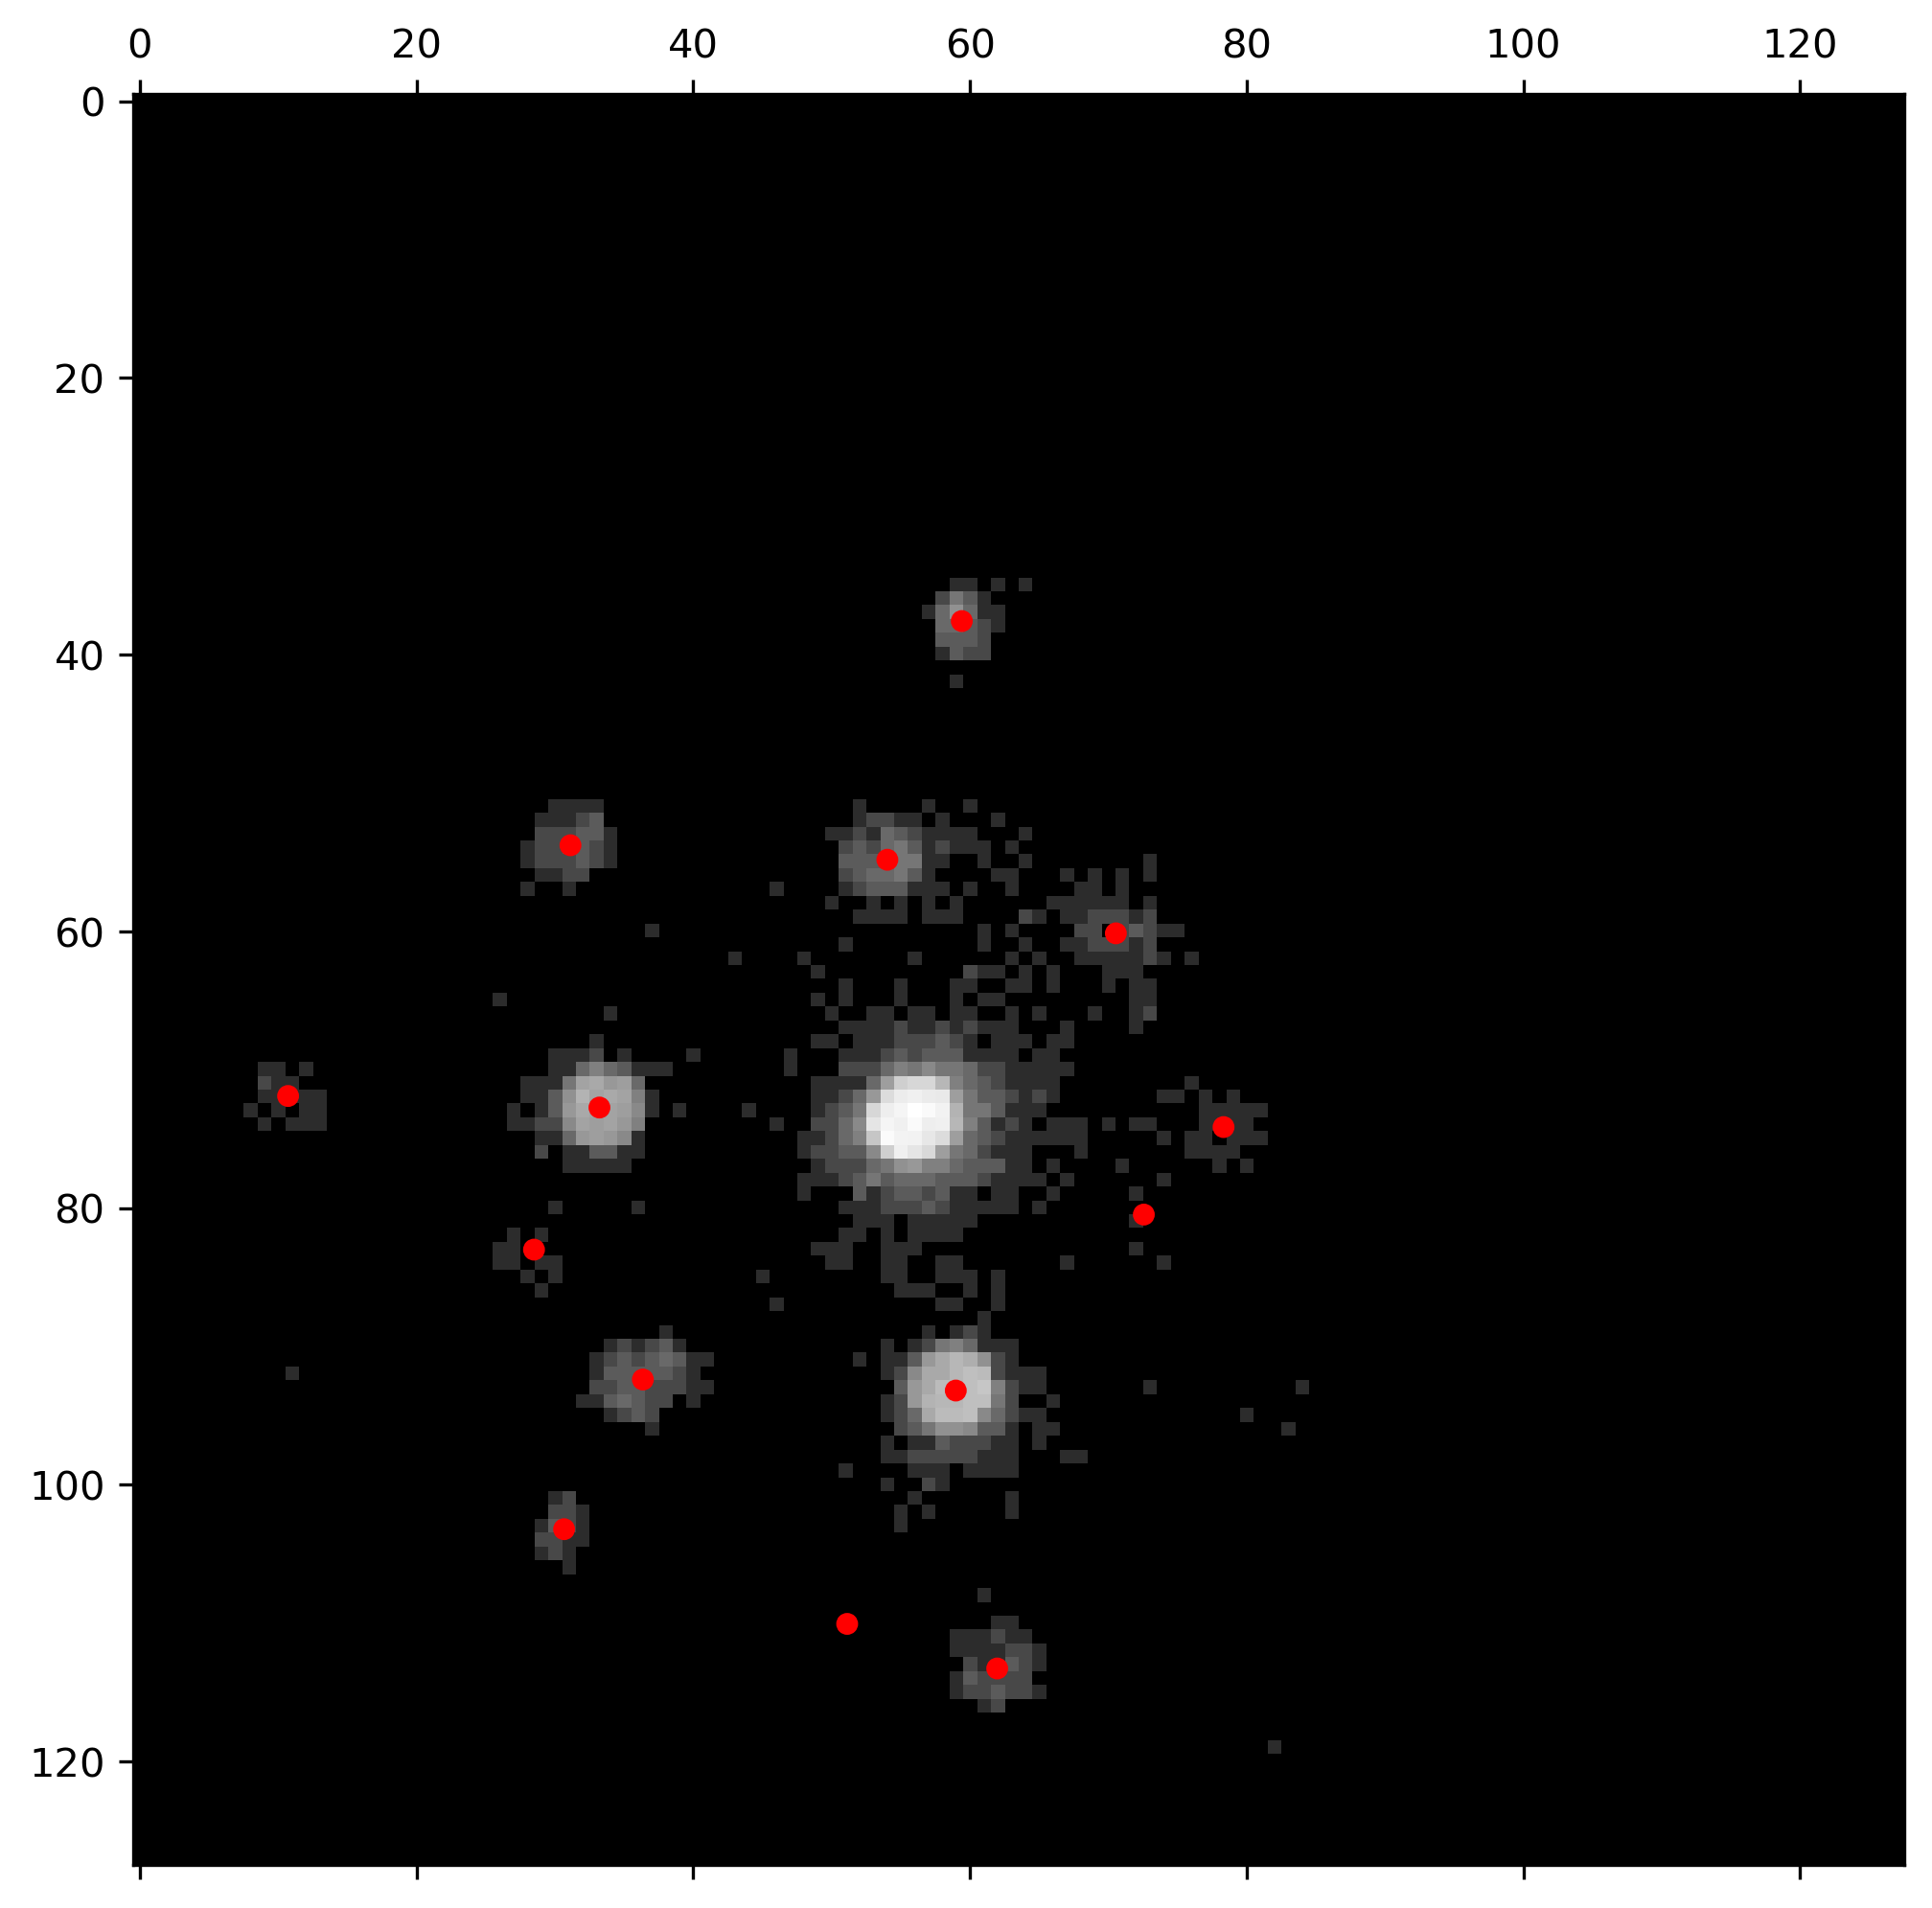

In [14]:
#display the bragg disk detection of pixel [50,60]
Rx, Ry = 50,60
corrPower=1
sigma=1
edgeBoundary=2
minRelativeIntensity=0.0001
relativeToPeak=0
minPeakSpacing=1
minAbsoluteIntensity = 0.3
maxNumPeaks=100
subpixel='poly'
upsample_factor=16
disks_selected=py4DSTEM.process.diskdetection.find_Bragg_disks_single_DP(datacube_symmetrize.data[Rx,Ry],probe_kernel,corrPower=corrPower,sigma=sigma,
                                                                       edgeBoundary=edgeBoundary,minRelativeIntensity=minRelativeIntensity,
                                                                       relativeToPeak=relativeToPeak,minPeakSpacing=minPeakSpacing,
                                                                       minAbsoluteIntensity=minAbsoluteIntensity,maxNumPeaks=maxNumPeaks,
                                                                       subpixel=subpixel,upsample_factor=upsample_factor)
#py4DSTEM.visualize.show_points(datacube_symmetrize.data[Rx][Ry], disks_selected.data['qx'], disks_selected.data['qy'],s=1,scale=20,alpha=1,pointcolor='r',scaling='log')
#py4DSTEM.visualize.show_points(datacube_info[Rx][Ry], disks_selected.data['qx'], disks_selected.data['qy'],s=1,scale=20,alpha=1,pointcolor='r',scaling='log')
py4DSTEM.visualize.show_points(datacube_symmetrize.data[Rx][Ry], braggpeaks_raw.pointlists[Rx][Ry].data['qx'], braggpeaks_raw.pointlists[Rx][Ry].data['qy'],s=1,scale=20,alpha=1,pointcolor='r',scaling='log')

# Obtain the Bragg vector map (BVM)

In [15]:
bvm_raw = get_bragg_vector_map_raw(braggpeaks_raw,datacube.Q_Nx,datacube.Q_Ny)

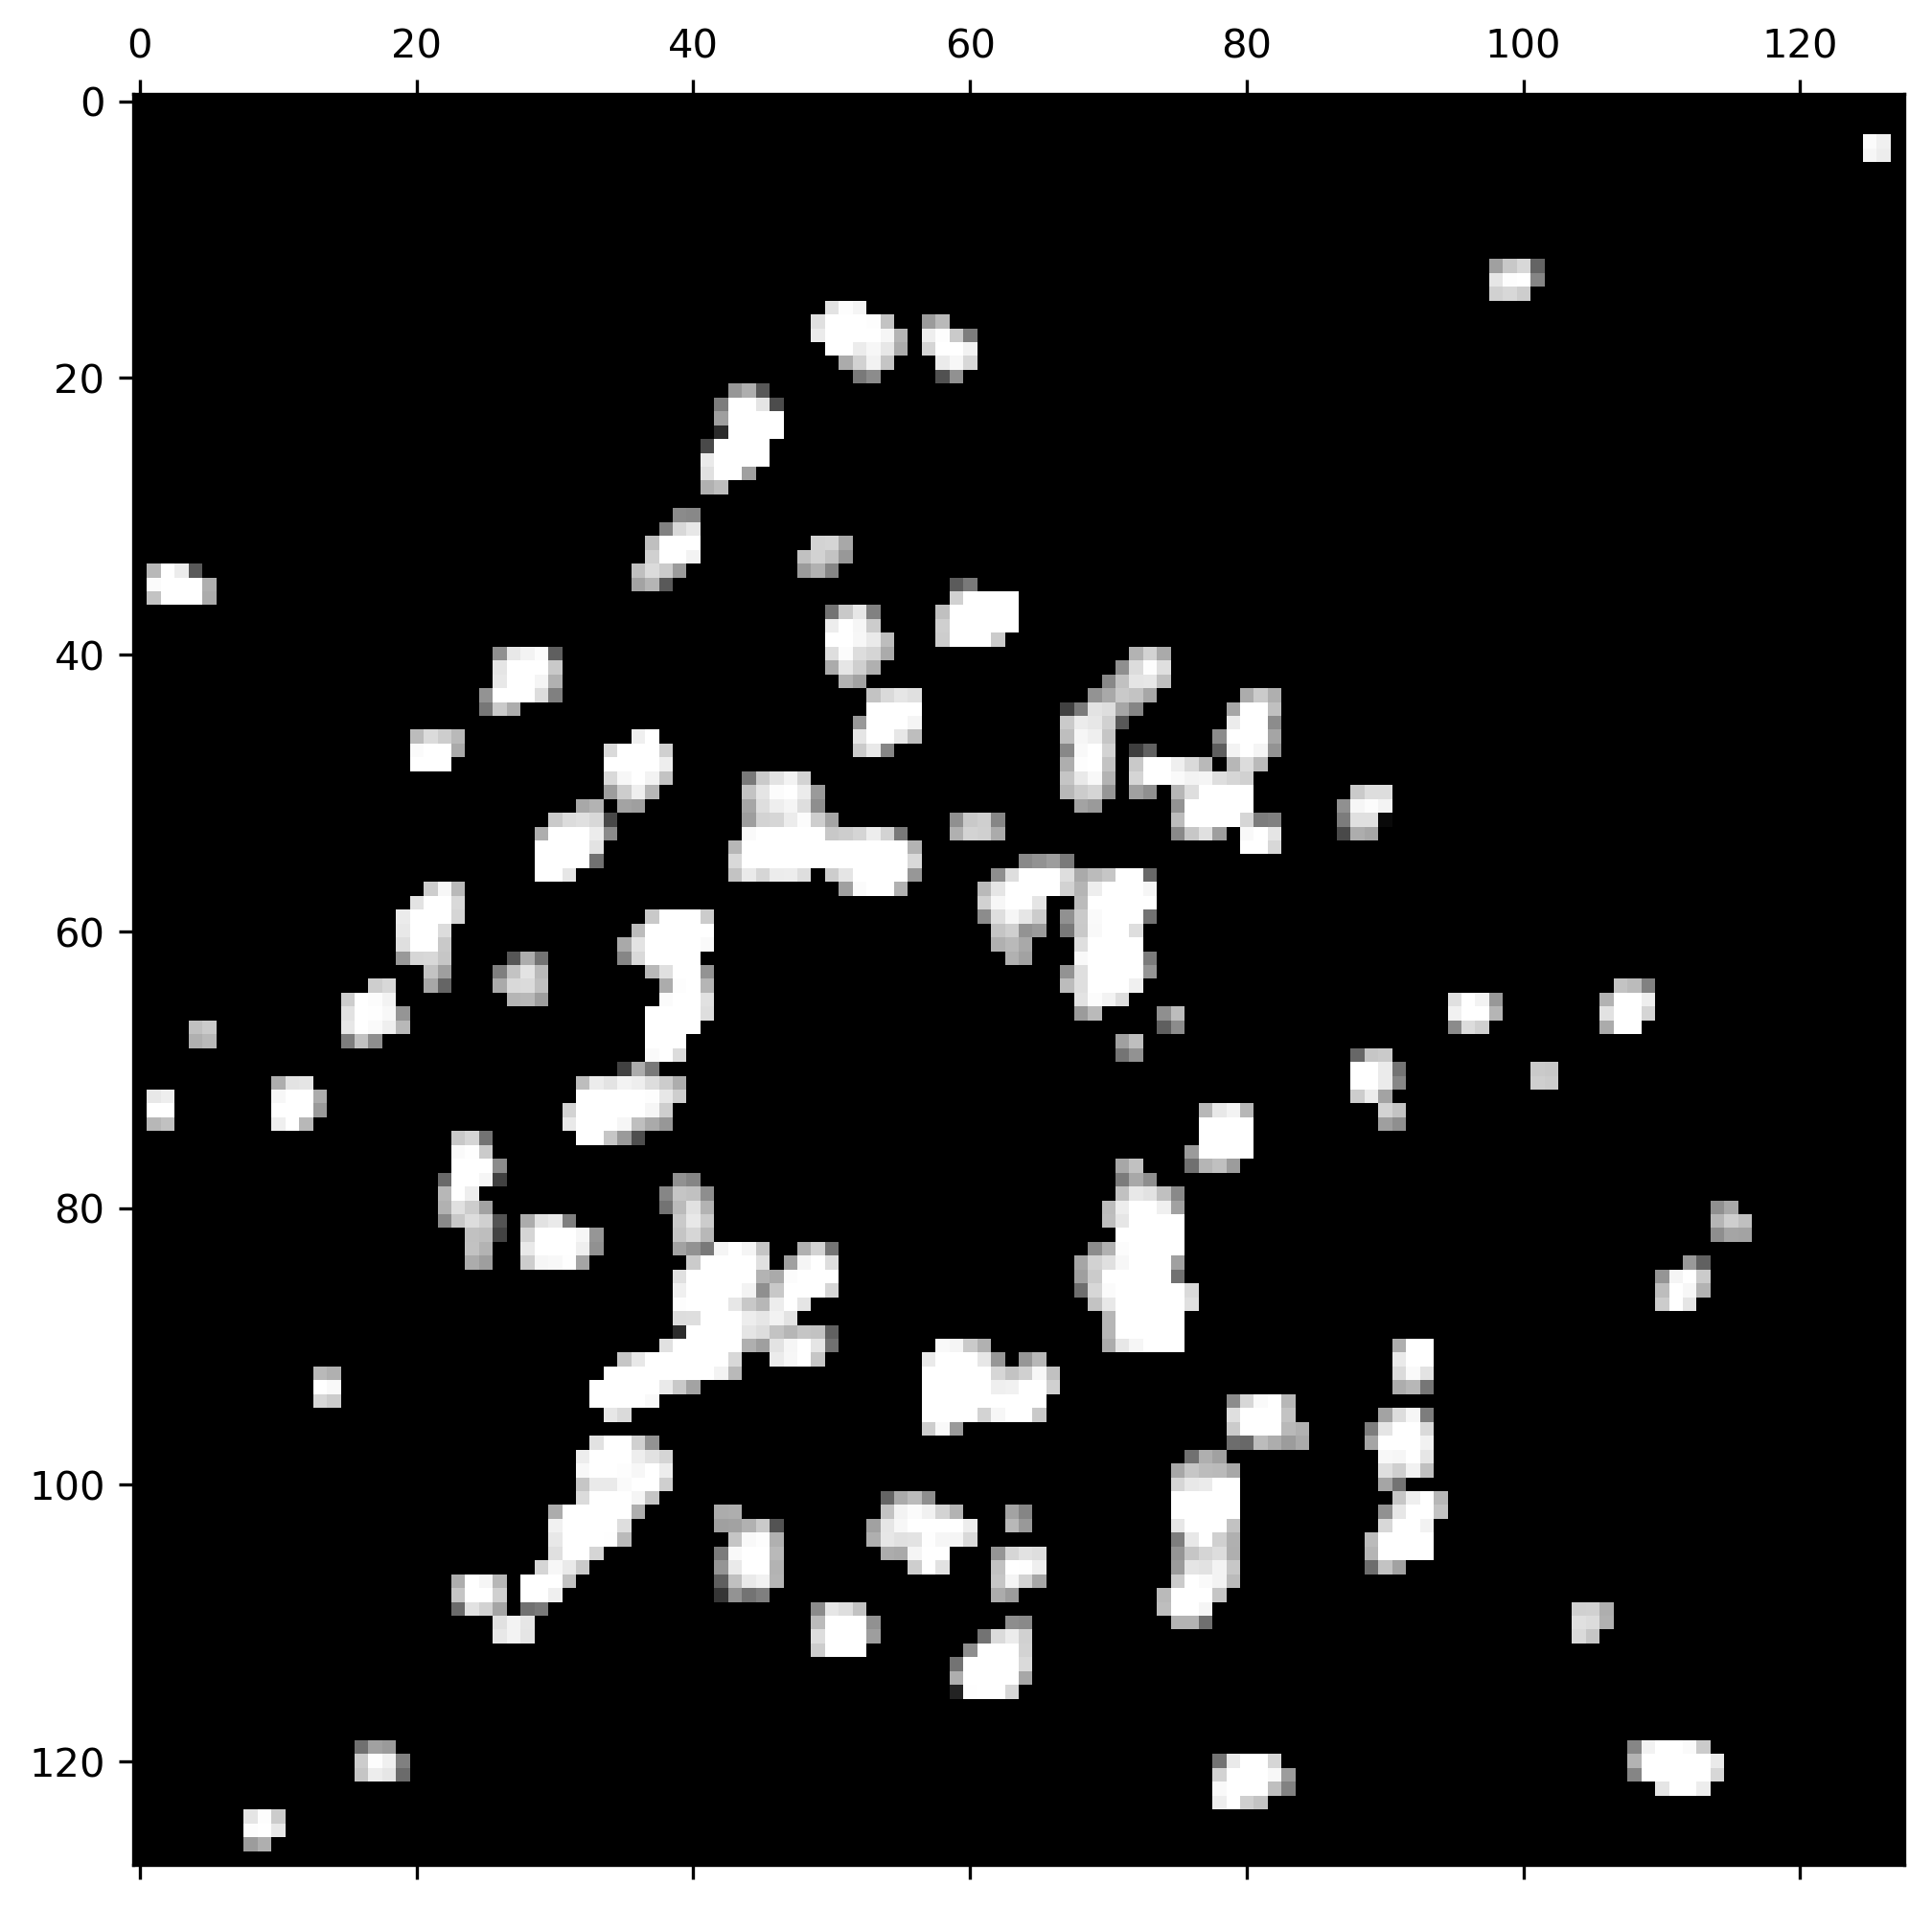

In [16]:
py4DSTEM.visualize.show(bvm_raw,cmap='gray',scaling='log',clipvals='manual',min=0,max=12)

In [17]:
#Obtain local maximum points from bragg vector map
gx,gy,gI = py4DSTEM.process.utils.get_maxima_2D(
                bvm_raw,
                edgeBoundary=1,
                minSpacing=0,
                minRelativeIntensity=0.001,
                relativeToPeak=0,
                maxNumPeaks=100,
                subpixel='none'
)

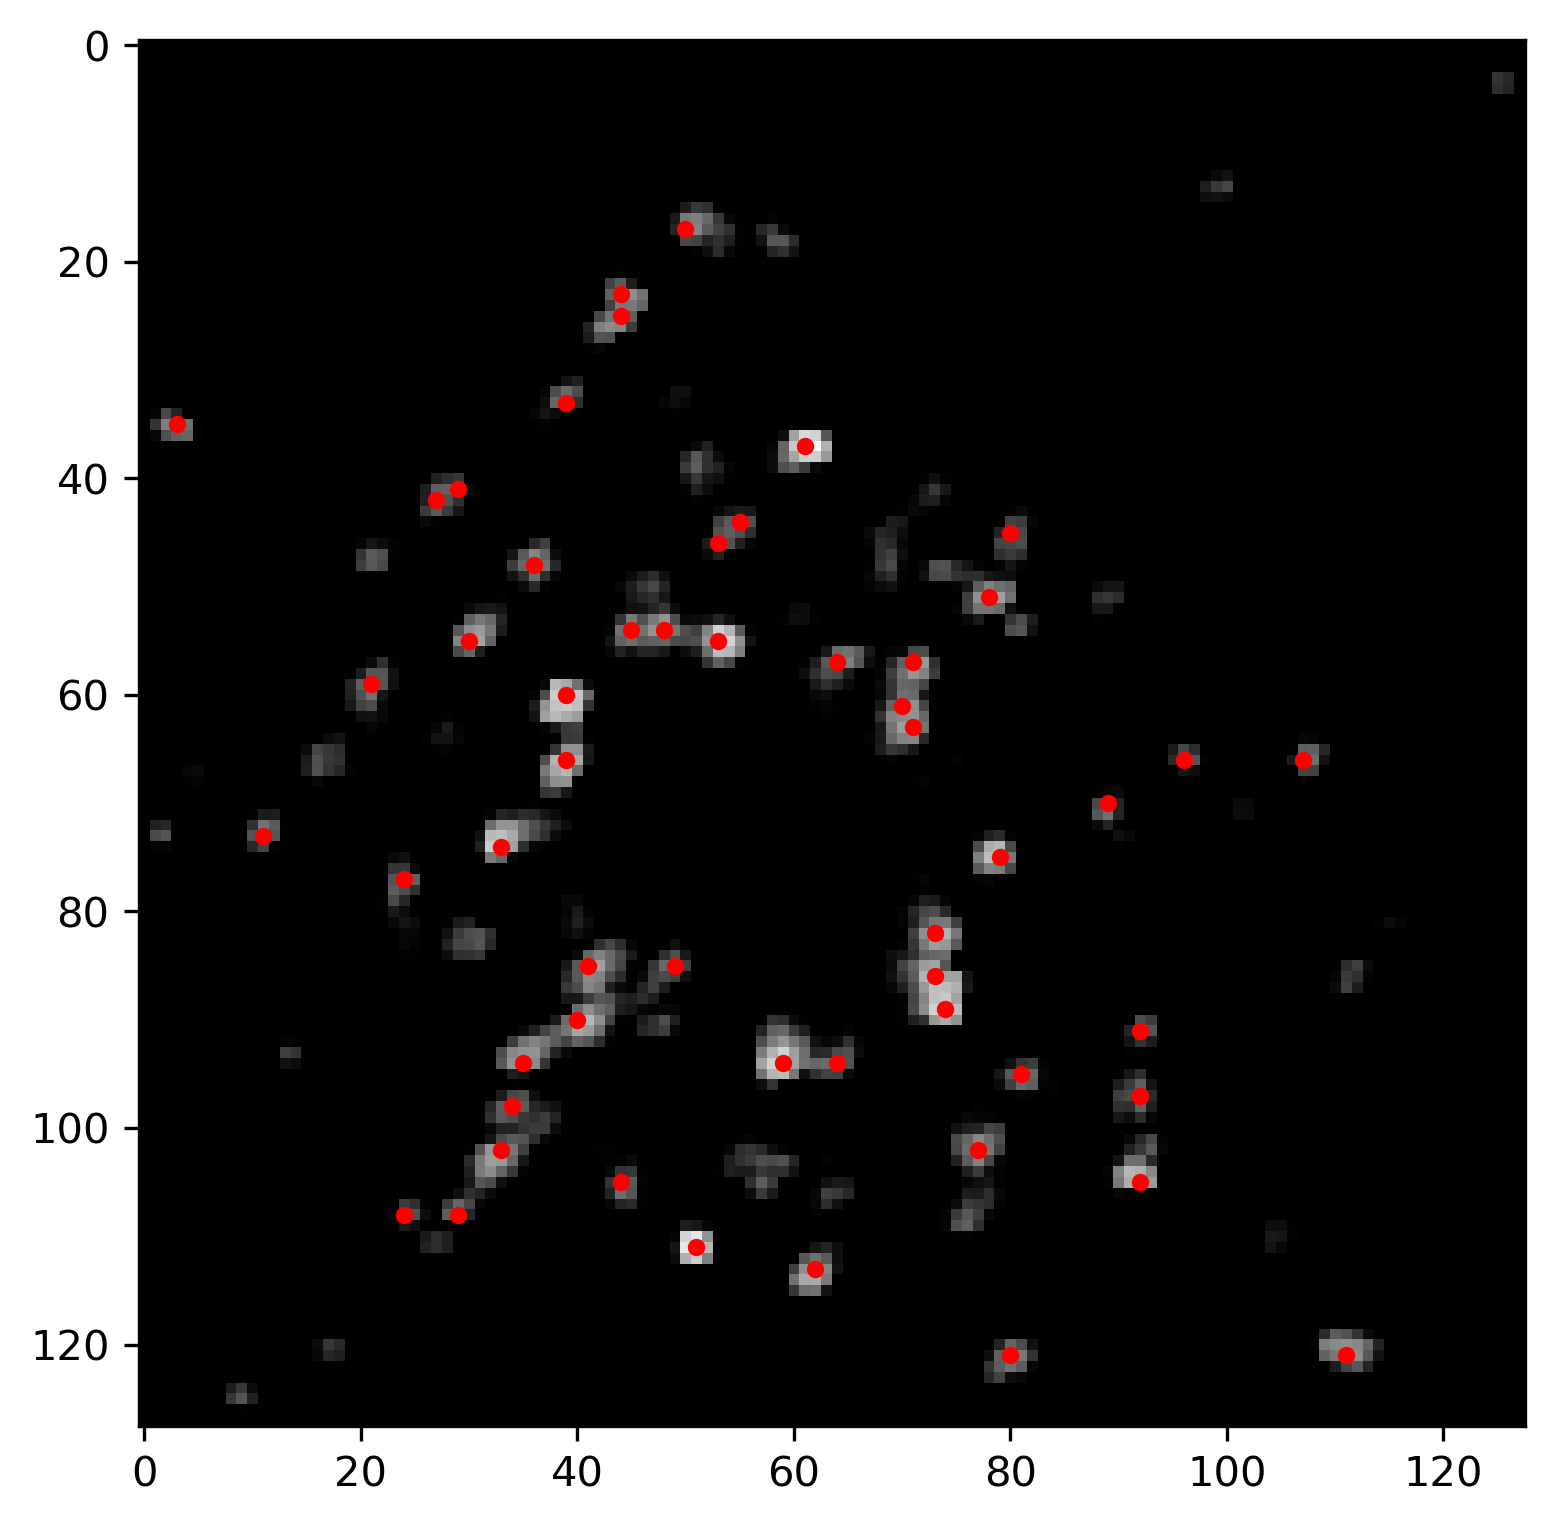

In [18]:
plt.imshow(np.log(bvm_raw+1), cmap='gray')
for i in range(len(gx)):
    Qx, Qy = int(gx[i]), int(gy[i])
    plt.scatter(Qy, Qx, c='r', s=10)

# py4dstem clustering

(9, 8130) (54, 9)


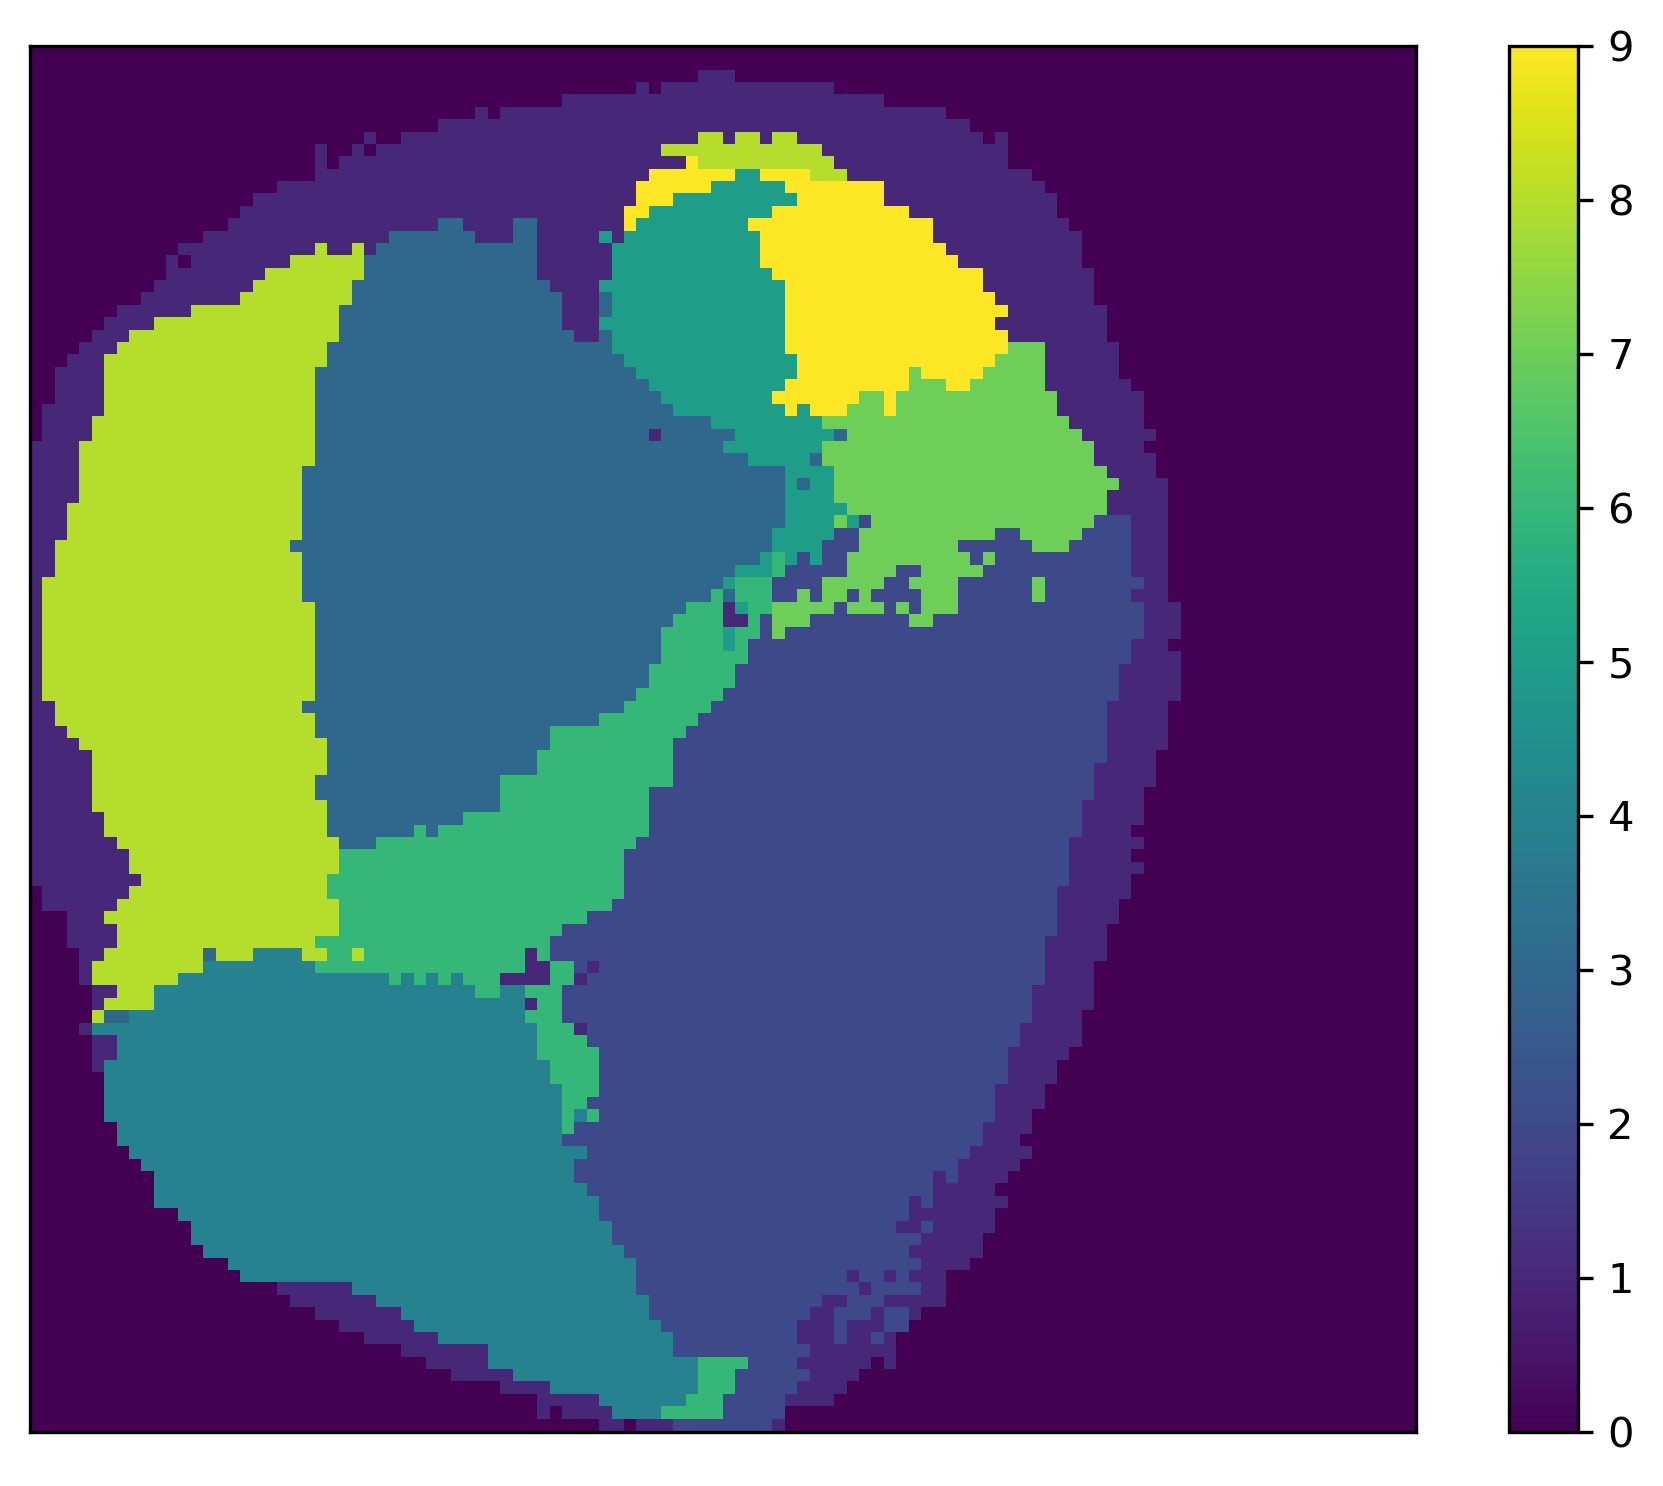

In [19]:
R_Nx, R_Ny = datacube_symmetrize.R_Nx, datacube_symmetrize.R_Ny
temp = BraggVectorClassification(braggpeaks_raw, particle_labels, R_Nx, R_Ny, gx, gy, max_dist=None)
temp.get_initial_classes_by_cooccurrence(
    thresh=0.3, #0.3
    BP_fraction_thresh=0.1, #0.1
    max_iterations=200,
    X_is_boolean=True,
    n_corr_init=2,
)
print(temp.H.shape, temp.W.shape)
H = temp.H / np.sum(temp.H, axis=0)[np.newaxis, :]
max_vals = np.argmax(temp.H, axis=0)
label = np.zeros((112, 112))
#label = np.zeros((90,90))
label[particle_labels==1] = max_vals + 1
plt.imshow(label)
#plt.scatter(np.array([5]), np.array([10]), c = 'r')
#plt.scatter(np.array([20]), np.array([30]), c = 'r')
plt.tick_params(bottom = False, left = False, labelleft = False, labelbottom = False)
plt.colorbar()
plt.show()
plt.close()

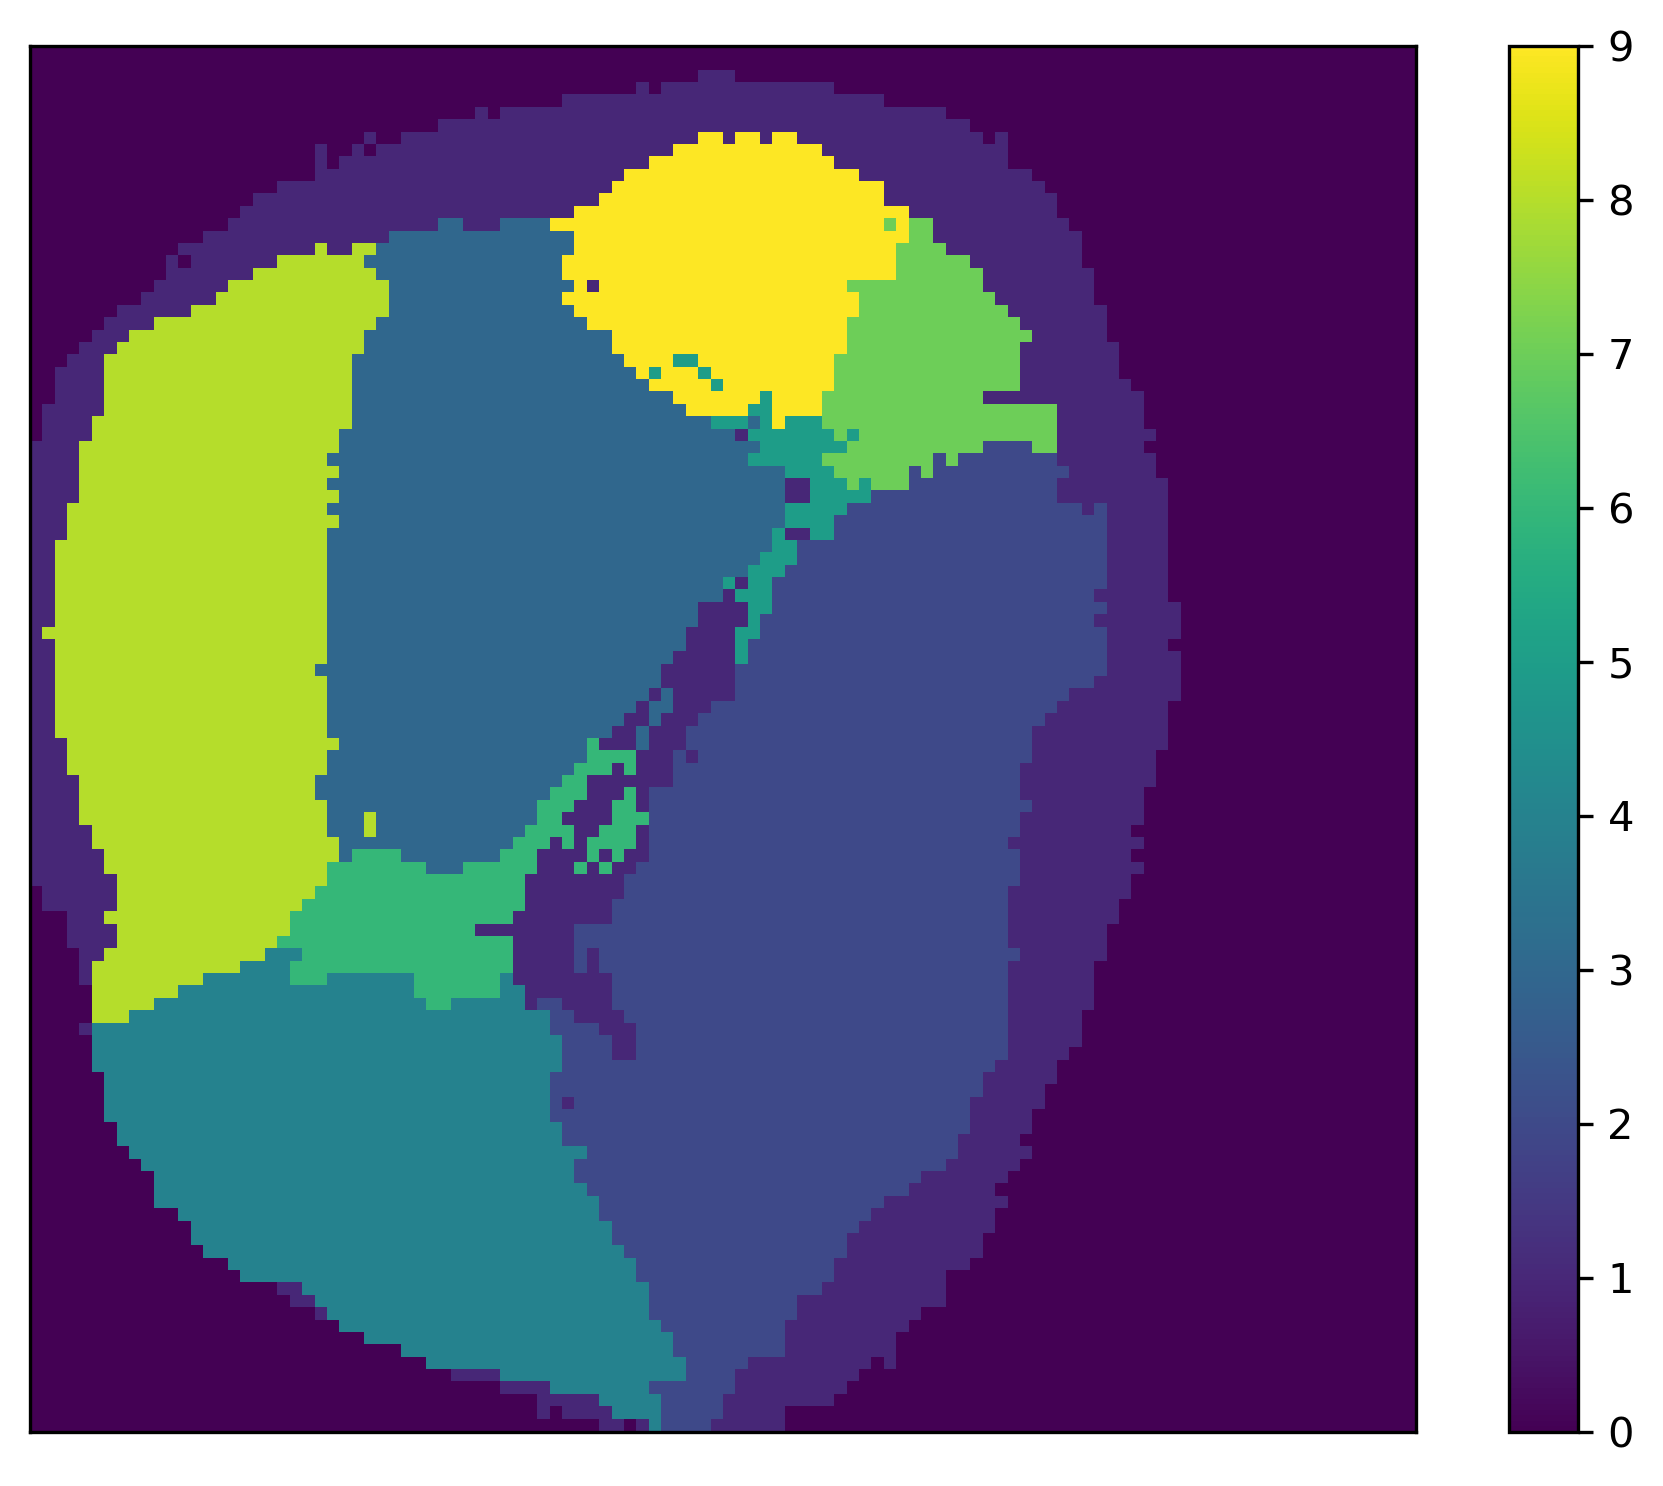

In [20]:
#refine the segmentation results using NMF
temp.nmf(1000)
H = temp.H_next / np.sum(temp.H_next, axis=0)[np.newaxis, :]
max_vals = np.argmax(temp.H_next, axis=0)
#label = np.zeros((112,112))
label = np.zeros((112,112))
label[particle_labels==1] = max_vals + 1
plt.imshow(label)
#plt.scatter(np.array([5]), np.array([10]), c = 'r')
#plt.scatter(np.array([20]), np.array([30]), c = 'r')
plt.tick_params(bottom = False, left = False, labelleft = False, labelbottom = False)
plt.colorbar()
plt.show()
plt.close()